In [1]:
from Heuristics import MST_BRKGA, ST_BRKGA, Greedy_BRKGA
from Heuristics.utils import generate_dissimilarity_matrix
from statsmodels.nonparametric.smoothers_lowess import lowess
import igraph
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr, kendalltau

from torch.utils.data import TensorDataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim


## Set up

In [8]:
# Define instance
instance_path = "./Instances_3/4.pkl"
instance_path = "./Instances_Mexico/15.pkl"
plots_path = "./Example_plots/"
os.makedirs(plots_path, exist_ok=True)
num_regions = 10
# Reproducibility
seed = 1

In [9]:
# Read instance
with open(instance_path, "rb") as f:
    graph = igraph.Graph.Read_Pickle(f)
print(f"Instance with {graph.vcount()} nodes")
print(f"Regionalization in {num_regions} regions\n")
diss_matrix = generate_dissimilarity_matrix(graph)

Instance with 125 nodes
Regionalization in 10 regions



In [10]:
config = {
    "population_size": 250,
    "elite_fraction": 0.2,
    "mutant_fraction": 0.2,
    "crossover_rate": 0.7,
    "max_generations": 500,
    "tolerance_generations": 100,
    "max_time": 9000,  
    "seed": seed
}

## Create Data

In [11]:
brkga = Greedy_BRKGA(graph, num_regions, diss_matrix, **config)

In [12]:
def get_X_y(n):
    X = brkga.generate_chromosome_array(n)
    y = np.apply_along_axis(brkga.chromosome_fitness, axis=1, arr=X) # type: ignore
    return X, y

In [13]:
X_train, y_train = get_X_y(1000)
print(X_train.shape)
print(y_train.shape)

(1000, 7875)
(1000,)


In [14]:
X_test, y_test = get_X_y(1000)

In [15]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [16]:
def evaluate_pred(y_test, y_pred):
    mse = mean_squared_error(y_test, y_pred)
    var_y = y_test.var()
    print(f"MSE: {mse:.4f}")
    print(f"Var(y): {var_y:.4f}")
    print(f"R²: {1 - mse / var_y:.4f}")

    # Rank correlations
    spearman_corr, _ = spearmanr(y_test, y_pred)
    kendall_corr, _ = kendalltau(y_test, y_pred)
    print(f"Spearman rho: {spearman_corr:.4f}")
    print(f"Kendall tau: {kendall_corr:.4f}")

    # Plot
    plt.scatter(y_test, y_pred, alpha=0.6)
    # identity
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='red', linewidth=1)
    # smoother
    smoothed = lowess(y_pred, y_test, frac=0.3, return_sorted=True)
    plt.plot(smoothed[:, 0], smoothed[:, 1], color='orange', linewidth=2, label='LOESS')
    plt.xlabel("True values")
    plt.ylabel("Predicted values")
    plt.title("Prediction vs True")
    plt.show()

## Predict

### Ridge

In [13]:
from sklearn.linear_model import Ridge

In [ ]:
ridge = Ridge()
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)

MSE: 3.1658
Var(y): 1.8068
R²: -0.7521
Spearman rho: 0.0034
Kendall tau: 0.0017


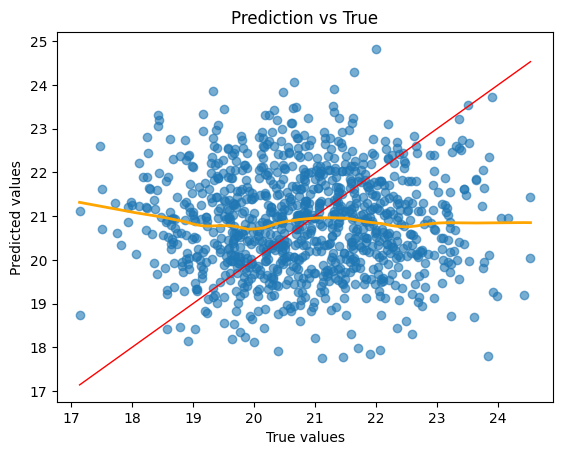

In [12]:
evaluate_pred(y_test, y_pred)

In [14]:
from sklearn.linear_model import RidgeCV

In [18]:
alphas = np.logspace(-4, 4, 10)
ridge_cv = RidgeCV(alphas=alphas, scoring='neg_mean_squared_error', cv=5)
ridge_cv.fit(X_train, y_train)
best_lambda = ridge_cv.alpha_
print(best_lambda)

KeyboardInterrupt: 

In [ ]:
y_pred = ridge_cv.predict(X_test)

### Lasso

In [17]:
from sklearn.linear_model import LassoCV

In [34]:
alphas = np.logspace(-4, 1, 20)
lasso_cv = LassoCV(alphas=alphas, cv=5)
lasso_cv.fit(X_train, y_train)
best_lambda = lasso_cv.alpha_
print(best_lambda)

10.0


In [35]:
alphas = np.logspace(-4, 2, 20)
alphas

array([1.00000000e-04, 2.06913808e-04, 4.28133240e-04, 8.85866790e-04,
       1.83298071e-03, 3.79269019e-03, 7.84759970e-03, 1.62377674e-02,
       3.35981829e-02, 6.95192796e-02, 1.43844989e-01, 2.97635144e-01,
       6.15848211e-01, 1.27427499e+00, 2.63665090e+00, 5.45559478e+00,
       1.12883789e+01, 2.33572147e+01, 4.83293024e+01, 1.00000000e+02])

MSE: 0.6874
Var(y): 0.6858
R²: -0.0023
Spearman rho: nan
Kendall tau: nan


C:\Users\diego\AppData\Local\Temp\ipykernel_10964\3413580215.py:9: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_corr, _ = spearmanr(y_test, y_pred)


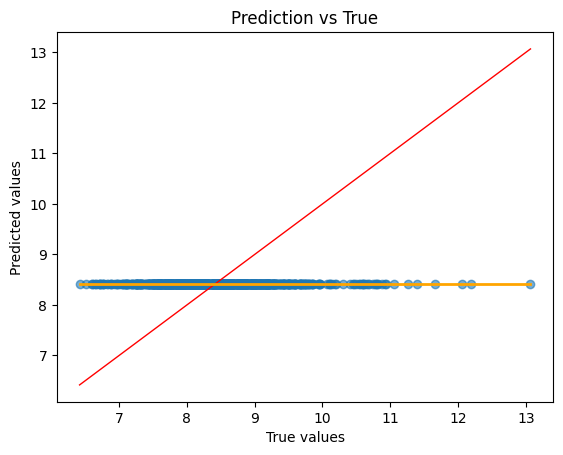

In [36]:
y_pred = lasso_cv.predict(X_test)
evaluate_pred(y_test, y_pred)

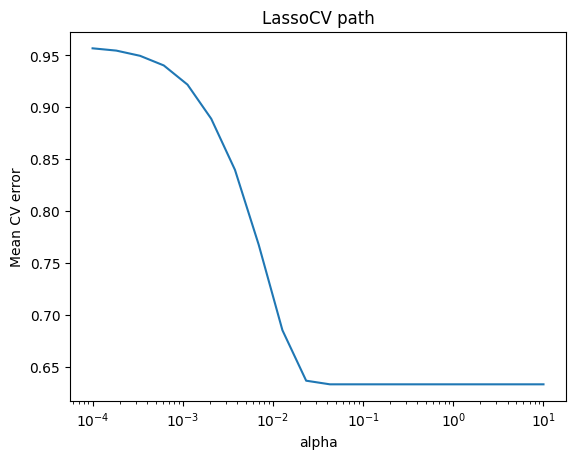

In [37]:
import matplotlib.pyplot as plt
plt.semilogx(lasso_cv.alphas_, np.mean(lasso_cv.mse_path_, axis=1))
plt.xlabel("alpha")
plt.ylabel("Mean CV error")
plt.title("LassoCV path")
plt.show()

### NN

In [40]:
class MLP(nn.Module):
    def __init__(self, n_features, hidden=[64, 32]):
        super().__init__()
        # Insert all layers
        layers = []
        in_dim = n_features
        for h in hidden:
            layers += [nn.Linear(in_dim, h), nn.ReLU()]
            in_dim = h
        layers += [nn.Linear(in_dim, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        # push for all layers
        return self.net(x)

In [16]:
model = MLP(X_train.shape[1], hidden=[500, 500, 500, 500, 500, 100])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
model

MLP(
  (net): Sequential(
    (0): Linear(in_features=23653, out_features=500, bias=True)
    (1): ReLU()
    (2): Linear(in_features=500, out_features=500, bias=True)
    (3): ReLU()
    (4): Linear(in_features=500, out_features=500, bias=True)
    (5): ReLU()
    (6): Linear(in_features=500, out_features=500, bias=True)
    (7): ReLU()
    (8): Linear(in_features=500, out_features=500, bias=True)
    (9): ReLU()
    (10): Linear(in_features=500, out_features=100, bias=True)
    (11): ReLU()
    (12): Linear(in_features=100, out_features=1, bias=True)
  )
)

In [17]:
train_losses = []
test_losses = []
# Dataset and loader
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

for epoch in range(10000):
    # --- Training step --- (mini/batch gradient )
    model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

    # --- Evaluation step ---
    if (epoch + 1) % 10 == 0:
        model.eval()
        with torch.no_grad():
            y_pred_train = model(X_train_t)
            loss_train = criterion(y_pred_train, y_train_t)
            y_pred_test = model(X_test_t)
            loss_test = criterion(y_pred_test, y_test_t)
        print(f"Epoch {epoch+1}, Train Loss: {loss_train.item():.4f}, Test Loss: {loss_test.item():.4f}")

        # Append to compare
        train_losses.append(loss_train.item())
        test_losses.append(loss_test.item())


Epoch 10, Train Loss: 1.2266, Test Loss: 2.2197
Epoch 20, Train Loss: 0.4580, Test Loss: 2.6124
Epoch 30, Train Loss: 0.3612, Test Loss: 2.7324
Epoch 40, Train Loss: 0.4555, Test Loss: 2.8865
Epoch 50, Train Loss: 0.1775, Test Loss: 2.6468
Epoch 60, Train Loss: 0.1154, Test Loss: 2.8964
Epoch 70, Train Loss: 0.0431, Test Loss: 2.8150
Epoch 80, Train Loss: 0.3213, Test Loss: 3.3261
Epoch 90, Train Loss: 0.4062, Test Loss: 3.3924
Epoch 100, Train Loss: 0.1928, Test Loss: 3.3078
Epoch 110, Train Loss: 0.1852, Test Loss: 3.0828
Epoch 120, Train Loss: 0.0435, Test Loss: 2.8966
Epoch 130, Train Loss: 0.0349, Test Loss: 3.1628
Epoch 140, Train Loss: 0.0169, Test Loss: 3.0967
Epoch 150, Train Loss: 0.0097, Test Loss: 3.1052
Epoch 160, Train Loss: 0.1544, Test Loss: 3.2612
Epoch 170, Train Loss: 0.1203, Test Loss: 3.0767
Epoch 180, Train Loss: 0.1287, Test Loss: 3.0725


KeyboardInterrupt: 

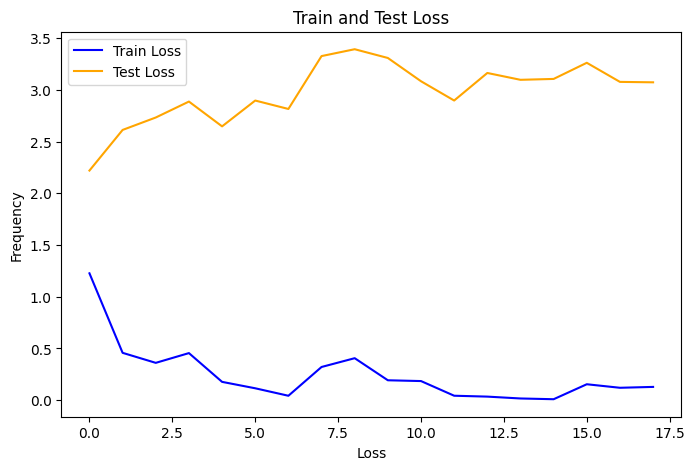

In [18]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, color='blue', label='Train Loss')
plt.plot(test_losses, color='orange', label='Test Loss')
plt.title('Train and Test Loss')
plt.xlabel('Loss')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [19]:
# Prediction
with torch.no_grad():
    y_pred = model(X_test_t).numpy()
    y_pred = y_pred.reshape(-1)

MSE: 3.0010
Var(y): 1.8898
R²: -0.5880
Spearman rho: 0.0239
Kendall tau: 0.0160


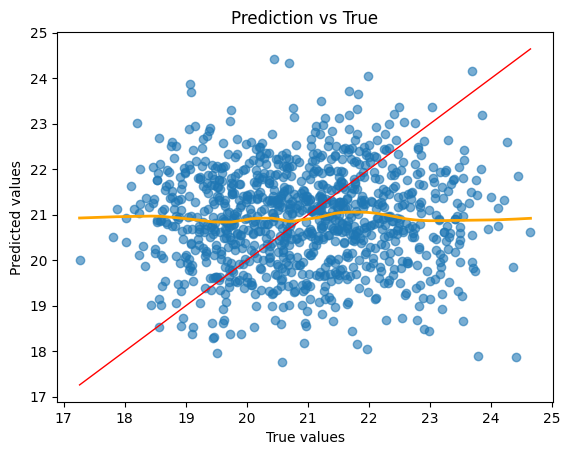

In [20]:
evaluate_pred(y_test, y_pred)

### NN + skip connection

In [90]:
class MLP_skip(nn.Module):
    def __init__(self, n_features, hidden=[64, 32]):
        super().__init__()
        dims = [n_features] + hidden
        # layers + skip
        self.layers = nn.ModuleList()
        self.projections = nn.ModuleList()

        for i in range(len(hidden)):
            # usual layer
            self.layers.append(nn.Linear(dims[i], dims[i+1]))
            # skip connection (projection if dimensions differ)
            if dims[i] != dims[i+1]:
                self.projections.append(nn.Linear(dims[i], dims[i+1]))
            else:
                self.projections.append(nn.Identity())

        # last layer
        self.out = nn.Linear(hidden[-1], 1)

    def forward(self, x):
        out = x
        for layer, proj in zip(self.layers, self.projections):
            out = torch.relu(layer(out))  + proj(out)
        return self.out(out)

In [91]:
model = MLP_skip(X_train.shape[1], hidden=[1000, 1000, 1000])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
model

MLP_skip(
  (layers): ModuleList(
    (0): Linear(in_features=7875, out_features=1000, bias=True)
    (1-2): 2 x Linear(in_features=1000, out_features=1000, bias=True)
  )
  (projections): ModuleList(
    (0): Linear(in_features=7875, out_features=1000, bias=True)
    (1-2): 2 x Identity()
  )
  (out): Linear(in_features=1000, out_features=1, bias=True)
)

In [ ]:
train_losses = []
test_losses = []
# Dataset and loader
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

for epoch in range(1000):
    # --- Training step --- (mini/batch gradient )
    model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

    # --- Evaluation step ---
    if (epoch + 1) % 1 == 0:
        model.eval()
        with torch.no_grad():
            y_pred_train = model(X_train_t)
            loss_train = criterion(y_pred_train, y_train_t)
            y_pred_test = model(X_test_t)
            loss_test = criterion(y_pred_test, y_test_t)
        print(f"Epoch {epoch+1}, Train Loss: {loss_train.item():.4f}, Test Loss: {loss_test.item():.4f}")

        # Append to compare
        train_losses.append(loss_train.item())
        test_losses.append(loss_test.item())


In [92]:
# Online learning
n = 400
epochs = 200
train_losses = []
test_losses = []

for epoch in range(epochs):
    # Get data
    X_train, y_train = get_X_y(n)
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    X_test, y_test = get_X_y(n)
    X_test_t = torch.tensor(X_test, dtype=torch.float32)
    y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

    # Train
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train_t)
    loss_train = criterion(y_pred, y_train_t)
    loss_train.backward()
    optimizer.step()

    # Evaluate
    model.eval()
    with torch.no_grad():
        y_pred_test = model(X_test_t)
        loss_test = criterion(y_pred_test, y_test_t)
    print(f"Epoch {epoch+1}, Train Loss: {loss_train.item():.4f}, Test Loss: {loss_test.item():.4f}")
    train_losses.append(loss_train.item())
    test_losses.append(loss_test.item())

Epoch 1, Train Loss: 67.6167, Test Loss: 14901.8438
Epoch 2, Train Loss: 14918.8896, Test Loss: 0.9260
Epoch 3, Train Loss: 0.9971, Test Loss: 4010.9468
Epoch 4, Train Loss: 4011.8174, Test Loss: 1137.5210
Epoch 5, Train Loss: 1138.3848, Test Loss: 18.2562
Epoch 6, Train Loss: 17.5655, Test Loss: 364.8272
Epoch 7, Train Loss: 360.6046, Test Loss: 474.3998
Epoch 8, Train Loss: 475.5304, Test Loss: 100.4744
Epoch 9, Train Loss: 99.4628, Test Loss: 22.2205
Epoch 10, Train Loss: 21.8656, Test Loss: 162.6897
Epoch 11, Train Loss: 161.6365, Test Loss: 128.1946
Epoch 12, Train Loss: 129.5811, Test Loss: 7.8088
Epoch 13, Train Loss: 8.0307, Test Loss: 59.2924
Epoch 14, Train Loss: 58.5213, Test Loss: 125.1382
Epoch 15, Train Loss: 123.8679, Test Loss: 43.3090
Epoch 16, Train Loss: 42.7671, Test Loss: 4.0924
Epoch 17, Train Loss: 3.7479, Test Loss: 57.9183
Epoch 18, Train Loss: 57.0283, Test Loss: 47.5500
Epoch 19, Train Loss: 49.3346, Test Loss: 1.6522
Epoch 20, Train Loss: 1.6920, Test Loss: 

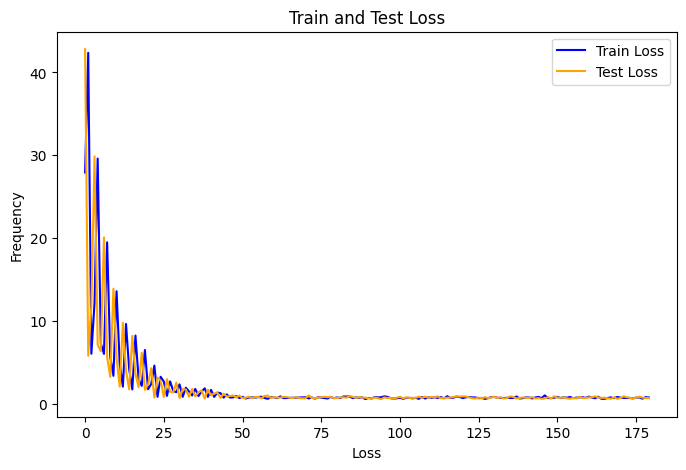

In [94]:
plt.figure(figsize=(8,5))
plt.plot(train_losses[20:], color='blue', label='Train Loss')
plt.plot(test_losses[20:], color='orange', label='Test Loss')
plt.title('Train and Test Loss')
plt.xlabel('Loss')
plt.ylabel('Frequency')
plt.legend()
plt.show()

MSE: 0.7964
Var(y): 0.7673
R²: -0.0380
Spearman rho: 0.0240
Kendall tau: 0.0168


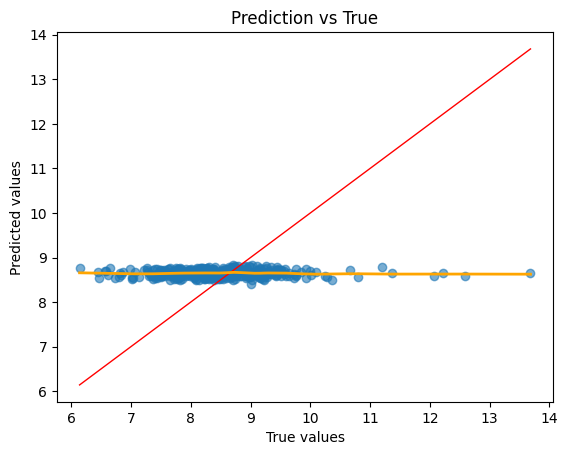

In [99]:
evaluate_pred(y_train, model(X_train_t).detach().numpy().reshape(-1))

MSE: 0.7073
Var(y): 0.6791
R²: -0.0414
Spearman rho: -0.0089
Kendall tau: -0.0049


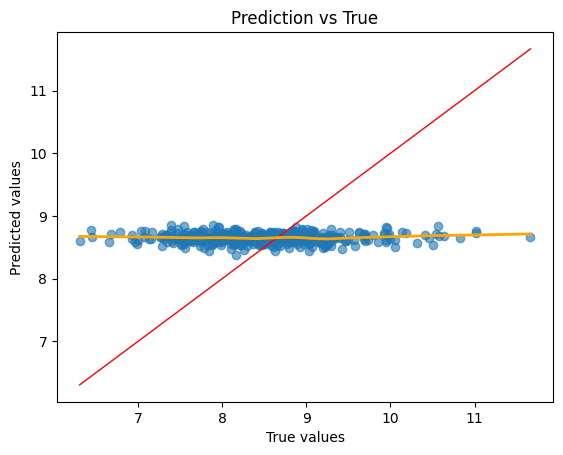

In [98]:
evaluate_pred(y_test, model(X_test_t).detach().numpy().reshape(-1))